# Active Image Classification via Self-supervised Learning

> **_Google Colab Note:_** If the notebook fails to run after installing the needed packages, try to restart the runtime (Ctrl + M) under Runtime -> Restart session.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](<colab_link>)

**Notebook Dependencies**

Uncomment the following cells to install all dependencies for this tutorial.

In [1]:
# !pip install scikit-activeml torch torchvision torchaudio tqdm

<hr style="border-style: solid; border-top: 1px solid; border-right: 0; border-bottom: 0; border-left: 0;">

This tutorial aims to demonstrate a practical comparison study using our ```scikit-activeml``` library. The workflow involves utilizing a self-supervised learning model, specifically ```DINOv2``` from [1], to generate embeddings for the Flowers-102 dataset [2]. Subsequently, various active learning strategies will be employed to intelligently select samples for labeling.

**Key Steps:**
1. **Self-Supervised Learning Model:** Utilize the DINOv2 model to create embedding dataset for Flowers-102 dataset.

2. **Active Learning Strategies:** Employ different active learning strategies provided by our library, including:
    - Random Sampling
    - Uncertainty Sampling
    - Discriminative Active Learning (DiscriminativeAL)
    - CoreSet
    - TypiClust
    - Badge
    - ProbCover
    - DropQuery
    - Falcun

3. **Batch Sample Selection:** Use each active learning strategy to select a batch of samples for labeling.

4. **Plotting the results:** By the end of this notebook, we'll compare the accuracy of the aforementioned active learning strategies.

**References:**

[1] M. Oquab et al., 'DINOv2: Learning Robust Visual Features without Supervision'. Transactions on Machine Learning Research (TMLR)

[2] M. E. Nilsback and A. Zisserman, 'Automated Flower Classification over a Large Number of Classes'. Indian Conference on Computer Vision, Graphics and Image Processing (ICVGIP)

In [2]:
# Comment in for speedup, if you have cuML installed.
# %load_ext cuml.accel
import numpy as np
import matplotlib as mlp
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
import warnings

from sklearn.linear_model import LogisticRegression

from skactiveml.classifier import SklearnClassifier
from skactiveml.pool import (
    UncertaintySampling,
    RandomSampling,
    DiscriminativeAL,
    CoreSet,
    TypiClust,
    Badge,
    DropQuery,
    ProbCover,
    Falcun
)
from skactiveml.utils import call_func, cache_numpy_dataset

from torchvision.datasets import Flowers102
from tqdm import tqdm


warnings.filterwarnings("ignore")
mlp.rcParams["figure.facecolor"] = "white"

cuML: Accelerator installed.


## Prepare Data with DINOv2

In this step, we focus on preparing the datasets using the self-supervised learning model DINOv2. DINOv2, short for "self-distillation with no labels", is a state-of-the-art model that excels at learning meaningful representations from unlabeled data.

**Step 1: Transformation**

Apply necessary transformations to the datasets, including resizing images to a standardized format. This ensures consistency of input dimensions with the DINOv2 model.

In [3]:
transforms = transforms.Compose(
    [transforms.Resize(256),
     transforms.CenterCrop(224),
     transforms.ToTensor(),
     transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))]
)

**Step 2: Load pretrained Model**

To calculate embeddings, we'll use DINOv2. Below we load the second smallest DINOv2 model to generate embedding datasets for the Flowers-102 datasets.

In [4]:
torch.hub.set_dir('.')
dinov2_vits14 = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")

Using cache found in cache/facebookresearch_dinov2_main


**Step 3: Load Datasets and Cache Embeddings**

Cache and load embeddings for each image in the dataset.

In [5]:
ds_train = Flowers102(".", split="train", transform=transforms, download=False)
ds_test = Flowers102(".", split="val", transform=transforms, download=False)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
X_train, y_train_true = cache_numpy_dataset(
    dataset=ds_train,
    dataset_name="Flowers102-train",
    model_fn=dinov2_vits14,
    model_name="dinov2_vits14",
    batch_size=32,
    device=device,
    cache_dir=".",
)
X_test, y_test_true = cache_numpy_dataset(
    dataset=ds_test,
    dataset_name="Flowers102-test",
    model_fn=dinov2_vits14,
    model_name="dinov2_vits14",
    batch_size=32,
    device=device,
    cache_dir=".",
)

[cache] Load numpy arrays in cache/Flowers102-train-dinov2_vits14.npz.
[cache] Load numpy arrays in cache/Flowers102-test-dinov2_vits14.npz.


## Random Seed Management

To ensure experiment reproducibility, it's important to set random states for all components that might use them. For simplicity, we set a single fixed random state and use helper functions to generate new seeds and random states. It's important to note that the ```master_random_state``` should only be used to create new random states or random seeds.

In [6]:
master_random_state = np.random.RandomState(0)

def gen_seed(random_state:np.random.RandomState):
    """
    Generate a seed for a random number generator.

    Parameters:
    - random_state (np.random.RandomState): Random state object.

    Returns:
    - int: Generated seed.
    """
    return random_state.randint(0, 2**31)

def gen_random_state(random_state:np.random.RandomState):
    """
    Generate a new random state object based on a given random state.

    Parameters:
    - random_state (np.random.RandomState): Random state object.

    Returns:
    - np.random.RandomState: New random state object.
    """
    return np.random.RandomState(gen_seed(random_state))

## Classification Models and Query Strategies

The embeddings we have computed can be used as an input to a classification model. For this guide, we use `LogisticRegression` from `sklearn`. Moreover, we handle the creation of query strategies using factory functions to simplify the separation of query strategies across repetitions.

In [7]:
dataset_classes = 102
missing_label = -1
clf = SklearnClassifier(LogisticRegression(verbose=0, tol=1e-3, C=0.1, max_iter=100000), classes=np.arange(dataset_classes), random_state=gen_seed(master_random_state), missing_label=-1)

def create_query_strategy(name, random_state):
    return query_strategy_factory_functions[name](random_state)

query_strategy_factory_functions = {
    'RandomSampling': lambda random_state: RandomSampling(random_state=gen_seed(random_state), missing_label=missing_label),
    'UncertaintySampling': lambda random_state: UncertaintySampling(random_state=gen_seed(random_state), missing_label=missing_label),
    'DiscriminativeAL': lambda random_state: DiscriminativeAL(random_state=gen_seed(random_state), missing_label=missing_label),
    'CoreSet': lambda random_state: CoreSet(random_state=gen_seed(random_state), missing_label=missing_label),
    'TypiClust': lambda random_state: TypiClust(random_state=gen_seed(random_state), missing_label=missing_label),
    'Badge': lambda random_state: Badge(random_state=gen_seed(random_state), missing_label=missing_label),
    'DropQuery': lambda random_state: DropQuery(random_state=gen_seed(random_state), missing_label=missing_label),
    'ProbCover': lambda random_state: ProbCover(random_state=gen_seed(random_state), missing_label=missing_label),
    'Falcun': lambda random_state: Falcun(random_state=gen_seed(random_state), missing_label=missing_label)
}

## Experiment Parameters

For this experiment, we need to define how the strategies should be compared against one another. Here the number of repetitions (```n_reps```), the number of cycles (```n_cycles```), and the size of each query (```query_batch_size```) need to be defined. 

In [8]:
n_reps = 3
n_cycles = 30
query_batch_size = 8
query_strategy_names = query_strategy_factory_functions.keys()

## Experiment Loop

The actual experiment loops over all query strategies. The accuracy for the test set is stored for each cycle and repetition in the `results` dictionary.

In [9]:
results = {}

for qs_name in query_strategy_names:
    accuracies = np.full((n_reps, n_cycles), np.nan)
    for i_rep in range(n_reps):
        y_train = np.full(shape=y_train_true.shape, fill_value=missing_label)

        qs = create_query_strategy(qs_name, random_state=gen_random_state(np.random.RandomState(i_rep)))
        clf.fit(X_train, y_train)

        for c in tqdm(range(n_cycles), desc=f'Repeat {i_rep + 1} with {qs_name}'):
            query_idx = call_func(qs.query, X=X_train, y=y_train, batch_size=query_batch_size, clf=clf, discriminator=clf)
            y_train[query_idx] = y_train_true[query_idx]
            clf.fit(X_train, y_train)
            score = clf.score(X_test, y_test_true)
            accuracies[i_rep, c] = score

    results[qs_name] = accuracies

Repeat 3 with Falcun: 100%|██████████| 30/30 [00:00<00:00, 36.26it/s]


## Resulting Plotting

We use learning curves to compare strategies. We visualize the average accuracy over all repetitions. In addition, the legend provides insight into the area under the learning curve, which indicates the average accuracy over all cycles.

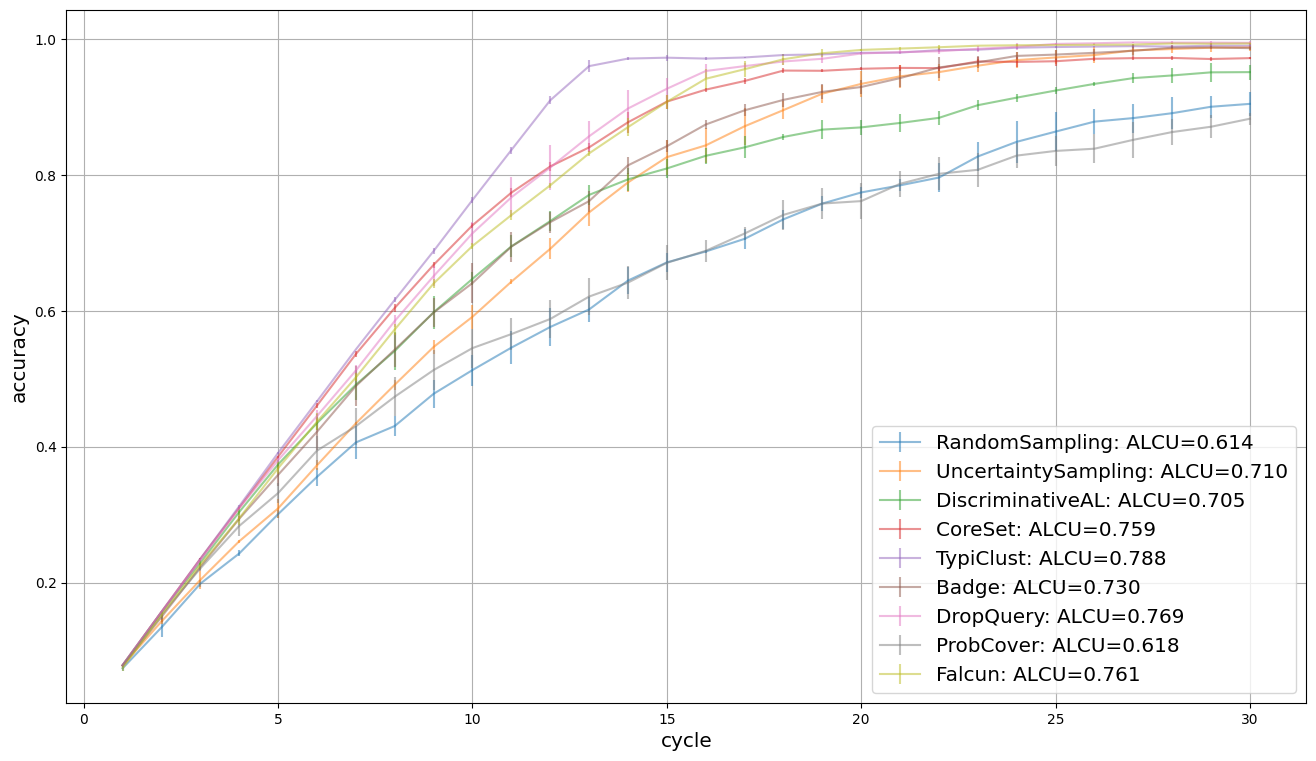

In [10]:
plt.figure(figsize=(16, 9))
for qs_name in query_strategy_names:
    key = qs_name
    result = results[key]
    reshaped_result = result.reshape((-1, n_cycles))
    errorbar_mean = np.mean(reshaped_result, axis=0)
    errorbar_std = np.std(reshaped_result, axis=0)
    plt.errorbar(np.arange(1, n_cycles+1), errorbar_mean, errorbar_std, label=f"{qs_name}: ALCU={np.mean(errorbar_mean):.3f}", alpha=0.5)
plt.grid()
plt.legend(loc='lower right', fontsize='x-large')
plt.xlabel('cycle', fontsize='x-large')
plt.ylabel('accuracy', fontsize='x-large')
plt.show()